# Baseline Classifier Vergleich

In diesem Notebook werden die Ergebnisse der drei Baseline Classifier (KNN, Logistic Regression, Naive Bayes) über alle drei Datensätze (Telco Churn, E-Commerce, Bank Marketing) verglichen.

Die Werte wurden direkt aus den jeweiligen Base-Notebooks übernommen:
- `knn_analysis.ipynb`
- `logreg_analysis.ipynb`
- `bayesfin.ipynb`

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Ergebnisse der Baseline Classifier

Alle 3 Baseline Classifier wurden mit dem random_state = 42 ausgeführt sind also hier consistent

In [2]:
# Ergebnisse direkt aus den Base-Notebooks übernommen (Summary-Tabellen)
# Quellen: knn_analysis.ipynb, logreg_analysis.ipynb, bayesfin.ipynb

rows = [
    # Telco Churn
    {'Dataset': 'Telco Churn',    'Classifier': 'KNN',                 'CV-AUC': 0.7677, 'Test-AUC': 0.7595, 'F1': 0.4950, 'Precision': 0.5596, 'Recall': 0.4439},
    {'Dataset': 'Telco Churn',    'Classifier': 'Logistic Regression', 'CV-AUC': 0.8410, 'Test-AUC': 0.8618, 'F1': 0.6341, 'Precision': 0.6821, 'Recall': 0.5925},
    {'Dataset': 'Telco Churn',    'Classifier': 'Naive Bayes',         'CV-AUC': 0.8098, 'Test-AUC': 0.7924, 'F1': 0.5842, 'Precision': 0.4658, 'Recall': 0.7834},
    # E-Commerce
    {'Dataset': 'E-Commerce',     'Classifier': 'KNN',                 'CV-AUC': 0.8885, 'Test-AUC': 0.8895, 'F1': 0.6187, 'Precision': 0.7088, 'Recall': 0.5490},
    {'Dataset': 'E-Commerce',     'Classifier': 'Logistic Regression', 'CV-AUC': 0.8929, 'Test-AUC': 0.8951, 'F1': 0.5074, 'Precision': 0.7582, 'Recall': 0.3812},
    {'Dataset': 'E-Commerce',     'Classifier': 'Naive Bayes',         'CV-AUC': 0.8765, 'Test-AUC': 0.8812, 'F1': 0.5757, 'Precision': 0.5472, 'Recall': 0.6073},
    # Bank Marketing
    {'Dataset': 'Bank Marketing', 'Classifier': 'KNN',                 'CV-AUC': 0.7683, 'Test-AUC': 0.7699, 'F1': 0.3368, 'Precision': 0.6299, 'Recall': 0.2299},
    {'Dataset': 'Bank Marketing', 'Classifier': 'Logistic Regression', 'CV-AUC': 0.9357, 'Test-AUC': 0.9306, 'F1': 0.4984, 'Precision': 0.6512, 'Recall': 0.4037},
    {'Dataset': 'Bank Marketing', 'Classifier': 'Naive Bayes',         'CV-AUC': 0.7618, 'Test-AUC': 0.7691, 'F1': 0.3983, 'Precision': 0.4598, 'Recall': 0.3513},
]

results_df = pd.DataFrame(rows)
display(results_df.set_index(['Dataset', 'Classifier']))

CV-AUC  Test-AUC      F1  Precision  \
Dataset        Classifier                                                 
Telco Churn    KNN                  0.7677    0.7595  0.4950     0.5596   
               Logistic Regression  0.8410    0.8618  0.6341     0.6821   
               Naive Bayes          0.8098    0.7924  0.5842     0.4658   
E-Commerce     KNN                  0.8885    0.8895  0.6187     0.7088   
               Logistic Regression  0.8929    0.8951  0.5074     0.7582   
               Naive Bayes          0.8765    0.8812  0.5757     0.5472   
Bank Marketing KNN                  0.7683    0.7699  0.3368     0.6299   
               Logistic Regression  0.9357    0.9306  0.4984     0.6512   
               Naive Bayes          0.7618    0.7691  0.3983     0.4598   

                                    Recall  
Dataset        Classifier                   
Telco Churn    KNN                  0.4439  
               Logistic Regression  0.5925  
               Naive Bayes          0.7834  
E-Commerce     KNN                  0.5490  
               Logistic Regression  0.3812  
               Naive Bayes          0.6073  
Bank Marketing KNN                  0.2299  
               Logistic Regression  0.4037  
               Naive Bayes          0.3513

## 3. Vergleich: Validation Accuracy pro Dataset

In [3]:
pivot = results_df.pivot(index='Dataset', columns='Classifier', values='Test-AUC')
print("Test-AUC Vergleich:")
display(pivot)

Test-AUC Vergleich:


Classifier,KNN,Logistic Regression,Naive Bayes
Dataset,,,
Bank Marketing,0.7699,0.9306,0.7691
E-Commerce,0.8895,0.8951,0.8812
Telco Churn,0.7595,0.8618,0.7924


## 4. Visualisierung

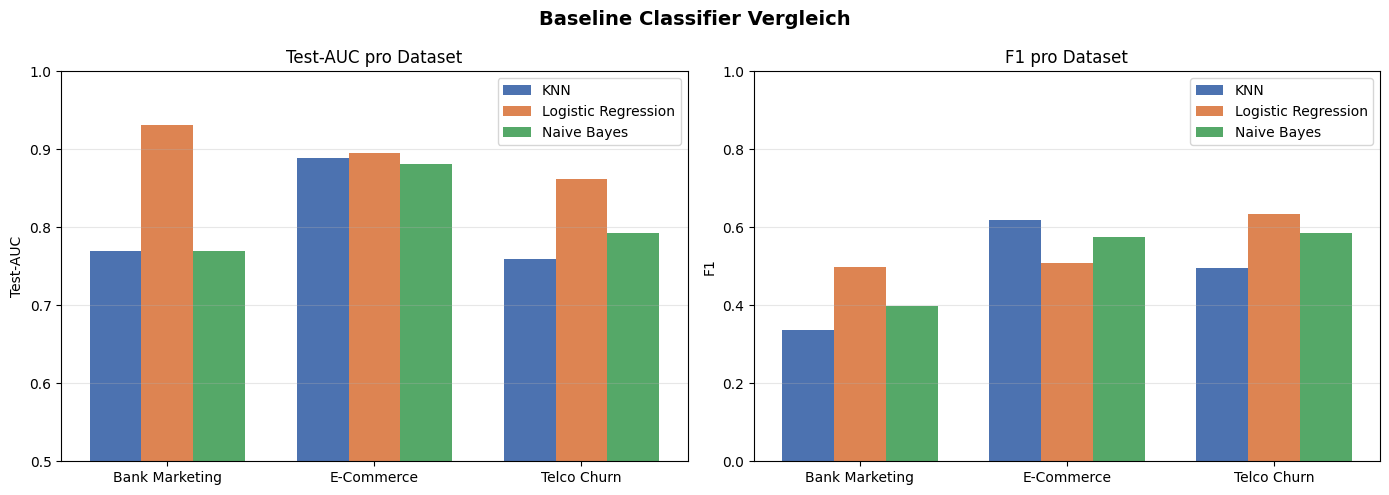

In [4]:
clf_names = ['KNN', 'Logistic Regression', 'Naive Bayes']
colors     = ['#4C72B0', '#DD8452', '#55A868']
x          = np.arange(len(pivot))
width      = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Balkendiagramm: Test-AUC
for i, (clf, color) in enumerate(zip(clf_names, colors)):
    axes[0].bar(x + i * width, pivot[clf], width, label=clf, color=color)
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(pivot.index)
axes[0].set_ylabel('Test-AUC')
axes[0].set_title('Test-AUC pro Dataset')
axes[0].legend()
axes[0].set_ylim(0.5, 1.0)
axes[0].grid(axis='y', alpha=0.3)

# Balkendiagramm: F1
pivot_f1 = results_df.pivot(index='Dataset', columns='Classifier', values='F1')
for i, (clf, color) in enumerate(zip(clf_names, colors)):
    axes[1].bar(x + i * width, pivot_f1[clf], width, label=clf, color=color)
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(pivot_f1.index)
axes[1].set_ylabel('F1')
axes[1].set_title('F1 pro Dataset')
axes[1].legend()
axes[1].set_ylim(0.0, 1.0)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Baseline Classifier Vergleich', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Durchschnittlicher Vergleich pro Classifier

In [5]:
avg_df = (
    results_df
    .groupby('Classifier')[['CV-AUC', 'Test-AUC', 'F1', 'Precision', 'Recall']]
    .mean()
    .round(4)
    .sort_values('Test-AUC', ascending=False)
)

print("Durchschnittliche Performance pro Classifier (über alle 3 Datasets):")
display(avg_df)

Durchschnittliche Performance pro Classifier (über alle 3 Datasets):


,CV-AUC,Test-AUC,F1,Precision,Recall
Classifier,,,,,
Logistic Regression,0.8899,0.8958,0.5466,0.6972,0.4591
Naive Bayes,0.8160,0.8142,0.5194,0.4909,0.5807
KNN,0.8082,0.8063,0.4835,0.6328,0.4076


## 6. Fazit

Der Vergleich der drei Baseline Classifier über alle Datensätze anhand von Test-AUC und F1 (statt Accuracy, siehe Klassenungleichgewicht) zeigt: **Logistic Regression** schneidet konsistent am besten ab und erzielt mit einem durchschnittlichen Test-AUC von **0.8958** und einem durchschnittlichen F1 von **0.5466** das stärkste Ergebnis.

Besonders deutlich wird der Vorsprung bei Bank Marketing, wo Logistic Regression mit einem Test-AUC von **0.9306** gegenüber KNN (0.7699) und Naive Bayes (0.7691) deutlich führt. Dieser Unterschied lässt sich darauf zurückführen, dass Logistic Regression besonders gut mit vielen binären Features umgeht, wie sie durch One-Hot-Encoding entstehen, und zusätzlich durch GridSearchCV auf den optimalen Regularisierungsparameter C abgestimmt wurde.

**Naive Bayes** belegt nach Test-AUC (Ø 0.8142) und F1 (Ø 0.5194) den zweiten Platz. Trotz der verletzten Unabhängigkeitsannahme zwischen Merkmalen erzielt es einen vergleichsweise hohen Recall (z. B. 0.7834 bei Telco), da es die Minderheitsklasse aggressiver vorhersagt als die anderen beiden Verfahren - auf Kosten der Precision.

**KNN** performt nach Test-AUC (Ø 0.8063) und F1 (Ø 0.4835) am schwächsten, was auf den Fluch der Dimensionalität zurückzuführen ist: Nach One-Hot-Encoding kategorialer Variablen verlieren euklidische Distanzen in hochdimensionalen Räumen an Aussagekraft, besonders sichtbar bei Bank Marketing (Test-AUC 0.7699, F1 nur 0.3368) mit seinen vielen kategorialen Merkmalen.

Insgesamt zeigt Bank Marketing die größte Spannbreite zwischen den Klassifikatoren (0.7691–0.9306 Test-AUC), während bei E-Commerce alle drei Verfahren aufgrund überwiegend numerischer Merkmale relativ nah beieinanderliegen (0.8812–0.8951 Test-AUC).